In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print("PyTorch version:",torch.__version__)
print("Import Successful")
device=torch.device('cpu')
print("Using device:",device)


PyTorch version: 2.11.0+cpu
Import Successful
Using device: cpu


In [2]:
# make circles make 2 concentric circles -inner circle class 1 and outer circle class 0

X,y=make_circles(n_samples=1000, noise=0.1, random_state=42,factor=0.6) #factor it reduces the size of inner circle which separates both classes a little more

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.bincount(y))

X shape: (1000, 2)
y shape: (1000,)
Class distribution: [500 500]


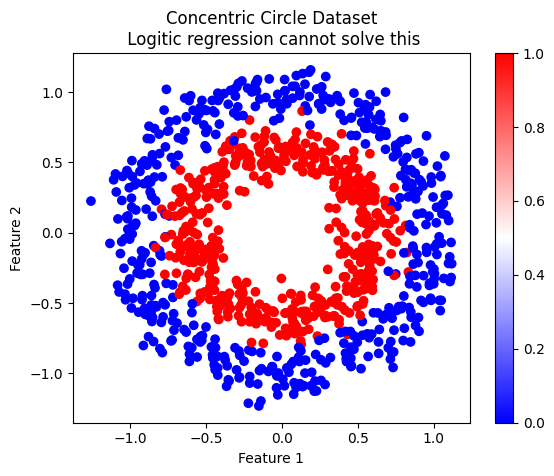

In [3]:
plt.scatter(X[:,0],X[:,1], c=y, cmap='bwr')
plt.colorbar()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Concentric Circle Dataset\n Logitic regression cannot solve this")
plt.show()

In [4]:
# Preparing data, train test split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# Scale feature 
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

#Convert numpy to pytorch tensors

X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)

print("X_train shape:", X_train_t.shape,"\n X_test_shape:",X_test_t.shape,"\n y_train shape:",y_train_t.shape,"\n y_test shape:",y_test_t.shape)

X_train shape: torch.Size([800, 2]) 
 X_test_shape: torch.Size([200, 2]) 
 y_train shape: torch.Size([800]) 
 y_test shape: torch.Size([200])


In [5]:
# Creating DataLoader 
# TensorDataset pairs X and y together so they stay in sync when shuffling

train_dataset = TensorDataset(X_train_t,y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset , batch_size=32, shuffle = False)

print("Number of training batches:", len(train_loader)) #800/32
print("Number of test batche:", len(test_loader)) #200/32

X_batch,y_batch = next(iter(train_loader))
#Single batch shapes:
print("X_batch : ",X_batch.shape)
print("y_batch : ",y_batch.shape)


Number of training batches: 25
Number of test batche: 7
X_batch :  torch.Size([32, 2])
y_batch :  torch.Size([32])


In [6]:
# Defining the Neural Network 

"""
a feedforward NN with two hidden layer
Architecture : 2 -> 16 -> 8 -> 1
- Input layer - 2 neurons (2 features)
- Hidden layer 1 : 16 neurons with relu
- Hidden layer 2 : 8 neutons with relu
- Output layer : 1 neuron with sigmoid (Binary classification)
"""
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,8),
    nn.ReLU(),
    nn.Linear(8,1),
    nn.Sigmoid()
)

print(model)



        

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


In [7]:
# Loss and optimizer

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(),lr=0.001)
print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [8]:
# Training Loop
# This is the training loop for almost all pytorch implementation 
# 1 - optimizer.zero_grad() clear old gradients
# 2 - y_pred = model(X) forward pass
# 3 - loss = criterion (y_pred,y) compute loss 
# 4 - loss.backward() compute gradients using backpropogation 
# 5 - optimizer.step() update weights

def train_model(model,train_loader, criterion,optimizer,epochs):
    cost_history=[]
    for epoch in range(epochs):
        model.train()  # Important step set the model in training mode, for example if there is dropout layer it will be activated
        epoch_loss=0.0

        for X_batch,y_batch in train_loader:

            optimizer.zero_grad() # zero the gradients as gradients from previous batch could be present
            y_pred=model(X_batch)
            loss=criterion(y_pred.squeeze(),y_batch) #y_batch is shape (32,) and y_pred is shape (32,1)
            loss.backward() # Back propogation
            optimizer.step() # Update weights by using gradients computed from backprop
            epoch_loss+=loss.item() # converts loss tensor to float
        avg_loss = epoch_loss/(len(train_loader))
        cost_history.append(avg_loss)

        if epoch%100==0:
            print("Epoch",epoch, "Loss :", f"{avg_loss:.4f}")
    return cost_history

print("Starting training...")
print("-" * 40)
cost_history = train_model(model, train_loader, criterion, optimizer, epochs=1000)
print("-" * 40)
print("Training complete")

Starting training...
----------------------------------------
Epoch 0 Loss : 0.6922
Epoch 100 Loss : 0.1050
Epoch 200 Loss : 0.0541
Epoch 300 Loss : 0.0422
Epoch 400 Loss : 0.0366
Epoch 500 Loss : 0.0357
Epoch 600 Loss : 0.0330
Epoch 700 Loss : 0.0329
Epoch 800 Loss : 0.0323
Epoch 900 Loss : 0.0322
----------------------------------------
Training complete


In [9]:
# Evaluation
def evaluate_model(model,X_tensor,y_true):

    model.eval() # Puts model in eval mode, must to turn this on as model could be in train mode where drop out and other setting may be active
    with torch.no_grad(): # no_grad tells the model to not save gradient while evaluating which saves a lot of time
        y_pred_proba=model(X_tensor).squeeze() # Squeeze as it has shape (m,1) -> (m)
        y_pred=(y_pred_proba>0.5).float() 
    accuracy = accuracy_score(y_true.numpy(),y_pred.numpy()) # passing numpy array instead of tensor

    return accuracy,y_pred.numpy()

train_accuracy, _=evaluate_model(model,X_train_t,y_train_t)
test_accuracy,y_pred_test = evaluate_model(model, X_test_t,y_test_t) 

print("Circle Dataset Result")

print("Train Accuracy :", f"{train_accuracy:.4f}")
print("Test Accuracy : ", f"{test_accuracy:.4f}")
    

Circle Dataset Result
Train Accuracy : 0.9900
Test Accuracy :  0.9350


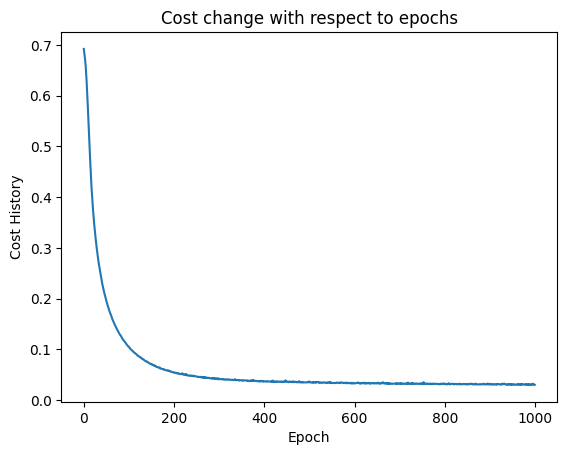

In [10]:
# We can see the cost decreases as epoch increases,
# We can also notice that after some epochs the cost does not decreas significantly as the model has already converged

plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost History")
plt.title("Cost change with respect to epochs")
plt.show()


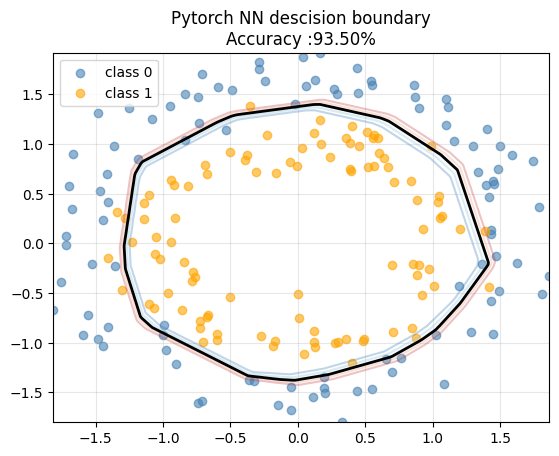

In [32]:
# Decision boundary 

x_min,x_max=X_test[:,0].min(),X_test[:,0].max() # x_min is the min value of feature 1, x_max is the max value of feature 1
y_min,y_max=X_test[:,1].min(),X_test[:,1].max() # y_ min is min value of feature 2, y_max is max value of feature 2
xx,yy=np.meshgrid( # converts 1 d arrays into 2d grid, xx represent x value across rows, yy represent y valure across columns
    np.linspace(x_min,x_max,200), # generating a equidistance space between min and max 
    np.linspace(y_min,y_max,200)
)
grid = torch.FloatTensor(np.c_[xx.ravel(),yy.ravel()]) #ravel flattens mattrix and np.c_ , does a column wise combine [x1,y1],
                                                                                                                    # [x2,y2],
                                                                                                                    # [x3,y3],...

model.eval()
with torch.no_grad():
    z=model(grid).squeeze().numpy() #predict for each value in grid for each point
    z=z.reshape(xx.shape)
plt.contour(xx,yy,z,cmap="RdBu",alpha=0.3) # Fills region with color blue class 0, red class 1
plt.contour(xx, yy, z, levels=[0.5], colors='black', linewidths=2) # Plot descision boundary

plt.scatter(X_test[y_test==0][:,0],X_test[y_test==0][:,1],label="class 0",color='steelblue',alpha=0.6) # PLot actual data, with class 0
plt.scatter(X_test[y_test==1][:,0],X_test[y_test==1][:,1],label='class 1', color = 'orange', alpha=0.6) # plot actual data with class 1, 
plt.title(f"Pytorch NN descision boundary\nAccuracy :{test_accuracy:.2%}")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

Dataset Shape: (1797, 64)
Labels Shape: (1797,)


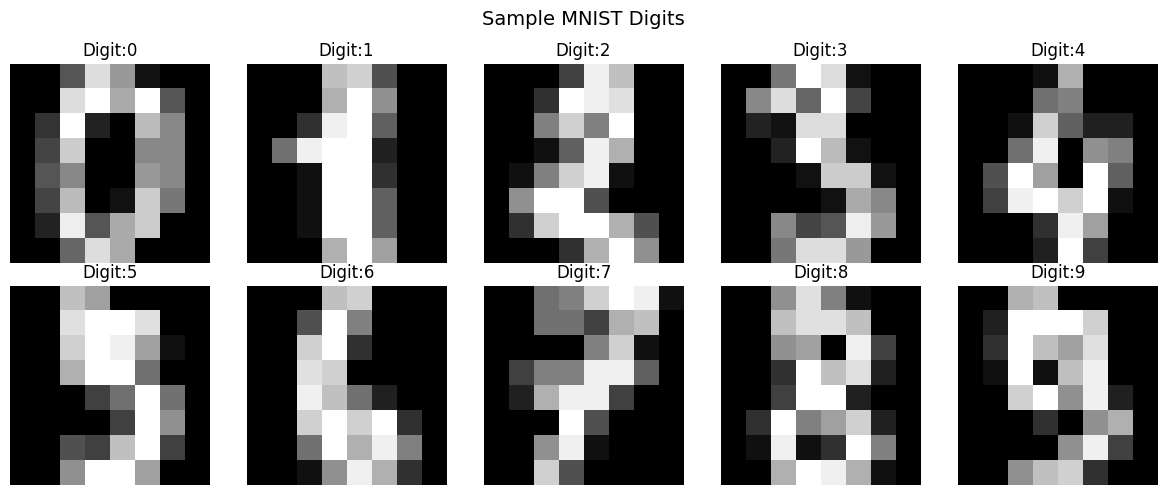

In [46]:
# Load and prepare MNIST data

from sklearn.datasets import load_digits

digits=load_digits()
X_d=digits.data
y_d=digits.target

print(f"Dataset Shape: {X_d.shape}")
print(f"Labels Shape: {y_d.shape}")

fix,axes= plt.subplots(2,5,figsize=(12,5))
for digit in range(10):
    ax=axes[digit//5][digit%5]
    idx=np.where(y_d==digit)[0][0]
    ax.imshow(digits.images[idx],cmap='gray')
    ax.set_title(f'Digit:{digit}')
    ax.axis("off")

    
plt.suptitle("Sample MNIST Digits",fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
X_train_d,X_test_d,y_train_d,y_test_d=train_test_split(X_d,y_d,test_size=0.2,random_state=14,stratify=y_d)

# Scale feature 
scaler_d=StandardScaler()
X_train_d=scaler_d.fit_transform(X_train_d)
X_test_d=scaler_d.transform(X_test_d)

#Convert numpy to pytorch tensors

X_train_dt = torch.FloatTensor(X_train_d)
X_test_dt = torch.FloatTensor(X_test_d)
y_train_dt = torch.LongTensor(y_train_d)
y_test_dt = torch.LongTensor(y_test_d)

print("X_train shape:", X_train_dt.shape,"\n X_test_shape:",X_test_dt.shape,"\n y_train shape:",y_train_dt.shape,"\n y_test shape:",y_test_dt.shape)

X_train shape: torch.Size([1437, 64]) 
 X_test_shape: torch.Size([360, 64]) 
 y_train shape: torch.Size([1437]) 
 y_test shape: torch.Size([360])


In [51]:
# Creating DataLoader 
# TensorDataset pairs X and y together so they stay in sync when shuffling

train_dataset_d = TensorDataset(X_train_dt,y_train_dt)
test_dataset_d = TensorDataset(X_test_dt, y_test_dt)

train_loader_d = DataLoader(train_dataset_d, batch_size=32, shuffle=True)
test_loader_d = DataLoader(test_dataset_d , batch_size=32, shuffle = False)

print("Number of training batches:", len(train_loader_d)) #1437/32
print("Number of test batche:", len(test_loader_d))  #360/32

X_batch,y_batch = next(iter(train_loader_d))
#Single batch shapes:
print("X_batch : ",X_batch.shape)
print("y_batch : ",y_batch.shape)


Number of training batches: 45
Number of test batche: 12
X_batch :  torch.Size([32, 64])
y_batch :  torch.Size([32])


In [63]:
# Defining the Neural Network 

"""
a feedforward NN with two hidden layer
Architecture : 64 -> 128 -> 64 -> 10
- Input layer - 2 neurons (2 features)
- Hidden layer 1 : 16 neurons with relu
- Hidden layer 2 : 8 neutons with relu
- Output layer : 1 neuron with sigmoid (Binary classification)
"""
DigitClassifier = nn.Sequential(
    nn.Linear(64,128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Linear(64,10),
    
)

digit_model=DigitClassifier
print(digit_model)
print(digit_model.parameters())
total_parameters=0
for p in digit_model.parameters():
    total_parameters+=p.numel()
print(f'Total Parameters: {total_parameters}')

        

Sequential(
  (0): Linear(in_features=64, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)
<generator object Module.parameters at 0x79aa285c6c70>
Total Parameters: 17226


In [64]:
# Loss and optimizer

digit_criterion = nn.CrossEntropyLoss()

digit_optimizer = optim.Adam(digit_model.parameters(),lr=0.001)
print("Loss function:", digit_criterion)
print("Optimizer:", digit_optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [66]:
# Training Loop
# This is the training loop for almost all pytorch implementation 
# 1 - optimizer.zero_grad() clear old gradients
# 2 - y_pred = model(X) forward pass
# 3 - loss = criterion (y_pred,y) compute loss 
# 4 - loss.backward() compute gradients using backpropogation 
# 5 - optimizer.step() update weights

def train_multi_class(model,train_loader,criterion,optimizer,epochs):
    cost_history=[]
    for epoch in range(epochs):
        model.train()
        epoch_loss=0.0
        for X_batch,y_batch in train_loader:
            optimizer.zero_grad()
            y_pred=model(X_batch)
            loss=criterion(y_pred.squeeze(),y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss+=loss.item()
        avg_loss=epoch_loss/(len(train_loader))
        cost_history.append(avg_loss)
        if epoch %100==0:
            print(f' Epoch: {epoch:4d}, Loss: {avg_loss:4f}')

    return cost_history

print("Starting training...")
print("-" * 40)
cost_history = train_multi_class(digit_model, train_loader_d, digit_criterion, digit_optimizer, epochs=1000)
print("-" * 40)
print("Training complete")

Starting training...
----------------------------------------
 Epoch:    0, Loss: 1.886947
 Epoch:  100, Loss: 0.000434
 Epoch:  200, Loss: 0.001135
 Epoch:  300, Loss: 0.000184
 Epoch:  400, Loss: 0.000034
 Epoch:  500, Loss: 0.000021
 Epoch:  600, Loss: 0.000014
 Epoch:  700, Loss: 0.000001
 Epoch:  800, Loss: 0.000004
 Epoch:  900, Loss: 0.006723
----------------------------------------
Training complete


In [74]:
# Evaluation
def evaluate_multiclass(model,X_tensor,y_true):

    model.eval() # Puts model in eval mode, must to turn this on as model could be in train mode where drop out and other setting may be active
    with torch.no_grad(): # no_grad tells the model to not save gradient while evaluating which saves a lot of time
        
        logits=model(X_tensor)# shape : (n_samples,10)
        y_pred=torch.argmax(logits,dim=1) # shape: (n_samples,) - index of highest score
        
    accuracy = accuracy_score(y_true.numpy(),y_pred.numpy()) # passing numpy array instead of tensor

    return accuracy,y_pred.numpy()

train_accuracy_d, _=evaluate_multiclass(digit_model,X_train_dt,y_train_dt)
test_accuracy_d,y_pred_test_d = evaluate_multiclass(digit_model, X_test_dt,y_test_dt) 

print("MNIST Dataset Result 10 class")

print("Train Accuracy :", f"{train_accuracy_d:.4f}")
print("Test Accuracy : ", f"{test_accuracy_d:.4f}")
    

MNIST Dataset Result
Train Accuracy : 1.0000
Test Accuracy :  0.9861


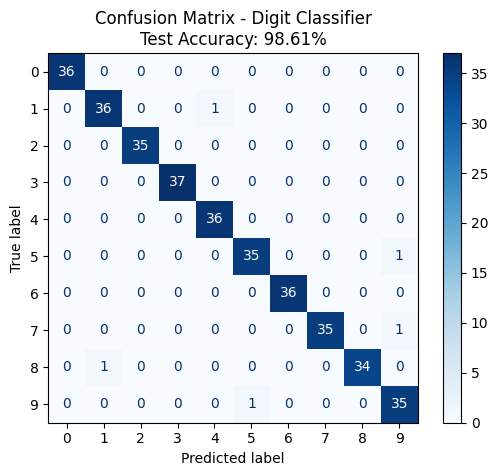


Per-class accuracy:
  Digit 0: 100.00%
  Digit 1: 97.30%
  Digit 2: 100.00%
  Digit 3: 100.00%
  Digit 4: 100.00%
  Digit 5: 97.22%
  Digit 6: 100.00%
  Digit 7: 97.22%
  Digit 8: 97.14%
  Digit 9: 97.22%


In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_dt.numpy(), y_pred_test_d)

# plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Confusion Matrix - Digit Classifier\nTest Accuracy: {test_accuracy_d:.2%}')
plt.show()

# Which digit is hardest to classify?
per_class_acc = cm.diagonal() / cm.sum(axis=1)
print("\nPer-class accuracy:")
for digit, acc in enumerate(per_class_acc):
    print(f"  Digit {digit}: {acc:.2%}")

In [79]:
torch.save(digit_model.state_dict(), 'digit_classifier.pth')
print("Model saved to digit_classifier.pth")

Model saved to digit_classifier.pth


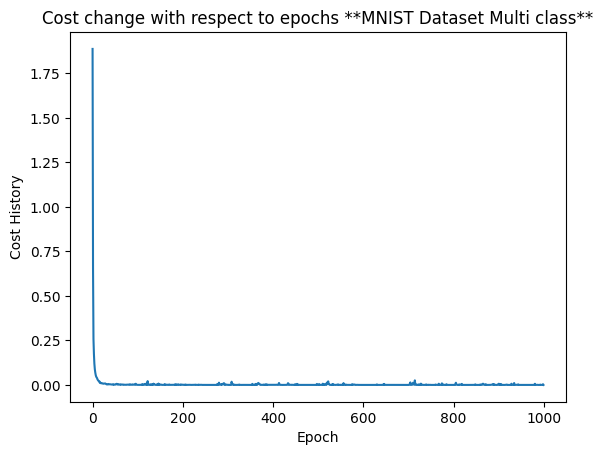

In [82]:
# We can see the cost decreases as epoch increases,
# We can also notice that after some epochs the cost does not decreas significantly as the model has already converged

plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost History")
plt.title("Cost change with respect to epochs **MNIST Dataset Multi class**")
plt.show()


In [81]:
print("=" * 55)
print("    PYTORCH NEURAL NETWORK - COMPLETE RESULTS")
print("=" * 55)

print("\n--- Part 1: Concentric Circles ---")
print(f"  Architecture:   2 → 16 → 8 → 1")
print(f"  Loss:           BCELoss")
print(f"  Train Accuracy: {train_accuracy:.2%}")
print(f"  Test Accuracy:  {test_accuracy:.2%}")

print("\n--- Part 2: MNIST 10-Class Digit Classifier ---")
print(f"  Architecture:   64 → 128 → 64 → 10")
print(f"  Loss:           CrossEntropyLoss")
print(f"  Dropout:        20%")
print(f"  Train Accuracy: {train_accuracy_d:.2%}")
print(f"  Test Accuracy:  {test_accuracy_d:.2%}")
print(f"  Hardest digit:  {per_class_acc.argmin()} ({per_class_acc.min():.2%} accuracy)")
print(f"  Easiest digit:  {per_class_acc.argmax()} ({per_class_acc.max():.2%} accuracy)")

print("\n--- Key Concepts ---")
print("  ✓ BCELoss + sigmoid     → binary classification")
print("  ✓ CrossEntropyLoss      → multiclass classification")
print("  ✓ LongTensor labels     → required for CrossEntropyLoss")
print("  ✓ argmax(logits, dim=1) → predicted class")
print("  ✓ Confusion matrix      → per-class error analysis")
print("=" * 55)

    PYTORCH NEURAL NETWORK - COMPLETE RESULTS

--- Part 1: Concentric Circles ---
  Architecture:   2 → 16 → 8 → 1
  Loss:           BCELoss
  Train Accuracy: 99.00%
  Test Accuracy:  93.50%

--- Part 2: MNIST 10-Class Digit Classifier ---
  Architecture:   64 → 128 → 64 → 10
  Loss:           CrossEntropyLoss
  Dropout:        20%
  Train Accuracy: 100.00%
  Test Accuracy:  98.61%
  Hardest digit:  8 (97.14% accuracy)
  Easiest digit:  0 (100.00% accuracy)

--- Key Concepts ---
  ✓ BCELoss + sigmoid     → binary classification
  ✓ CrossEntropyLoss      → multiclass classification
  ✓ LongTensor labels     → required for CrossEntropyLoss
  ✓ argmax(logits, dim=1) → predicted class
  ✓ Confusion matrix      → per-class error analysis


In [130]:
a=np.array([[1,1],[1,-1]])
b=np.array([[2],[3]])
c=a+b

In [131]:
c

array([[3, 3],
       [4, 2]])

In [133]:
a=np.random.randn(3,4)
b=np.random.randn(4,1)
c=np.random.randn(3,4)
for i in range(3):
    for j in range(4):
        c[i][j]=a[i][j]*b[j]
print(a)
print(b)
print(c)

[[ 1.85227818 -0.01349722 -1.05771093  0.82254491]
 [-1.22084365  0.2088636  -1.95967012 -1.32818605]
 [ 0.19686124  0.73846658  0.17136828 -0.11564828]]
[[-0.3011037 ]
 [-1.47852199]
 [-0.71984421]
 [-0.46063877]]
[[-0.55772781  0.01995594  0.76138709 -0.37889608]
 [ 0.36760053 -0.30880942  1.41065719  0.61181399]
 [-0.05927565 -1.09183908 -0.12335846  0.05327208]]


/tmp/ipykernel_346885/3711505320.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  c[i][j]=a[i][j]*b[j]


In [136]:
a*b.T

array([[-0.55772781,  0.01995594,  0.76138709, -0.37889608],
       [ 0.36760053, -0.30880942,  1.41065719,  0.61181399],
       [-0.05927565, -1.09183908, -0.12335846,  0.05327208]])